#  Single-Qubit State Tomography using Linear Inversion
*Reconstructing an unknown quantum state from measurements.*

This notebook demonstrates the complete process of single-qubit state tomography using linear inversion:
1. Creating a target quantum state
2. Simulating measurements in different bases
3. Reconstructing the density matrix and checking the physicality of the reconstructed state.
4. Visualizing results on the Bloch sphere

In [2]:
#imports 
import numpy as np
import matplotlib.pyplot as plt
from qutip import about, basis, sigmax, sigmay, sigmaz, qeye, Qobj, fidelity, ket2dm
from qutip.measurement import measure
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Math, Latex, Markdown, HTML

# Set up for inline plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

Define a function to check whether the reconstructed density matrix represents a physical state.

In [3]:
def check_physicality(rho, tol=1e-6):
    """
    Check if a density matrix is physical.
    
    Returns:
        dict: Results of various physicality checks
    """
    # Check 1: Hermiticity
    is_herm = rho.isherm
    
    # Check 2: Trace = 1
    trace = rho.tr()
    trace_ok = abs(trace - 1) < tol
    
    # Check 3: Positive semidefinite (eigenvalues ≥ 0)
    eigenvalues = rho.eigenenergies()
    pos_ok = np.all(eigenvalues >= -tol)
    
    # Check 4: Purity (should be ≤ 1)
    purity = (rho * rho).tr()
    purity_ok = purity <= 1 + tol
    
    # Check 5: Bloch vector length (should be ≤ 1)
    x = np.real((rho * sigmax()).tr())
    y = np.real((rho * sigmay()).tr())
    z = np.real((rho * sigmaz()).tr())
    bloch_length = np.sqrt(x**2 + y**2 + z**2)
    bloch_ok = bloch_length <= 1 + tol
    
    return {
        'is_physical': is_herm and trace_ok and pos_ok and purity_ok and bloch_ok,
        'is_hermitian': is_herm,
        'trace': trace,
        'trace_ok': trace_ok,
        'eigenvalues': eigenvalues,
        'positive_ok': pos_ok,
        'purity': purity,
        'purity_ok': purity_ok,
        'bloch_vector': (x, y, z),
        'bloch_length': bloch_length,
        'bloch_ok': bloch_ok
    }

Single-qubit state tomography for pure state using linear inversion: 

$$ \rho = |+i\rangle\langle +i| = \frac{1}{2} \begin{pmatrix} 1 & -i \\ i & 1 \end{pmatrix} $$

In [4]:
# Create target state |+i⟩ = (|0⟩ + i|1⟩)/√2
target_state = (basis(2, 0) + 1j*basis(2, 1)).unit()
target_dm = target_state * target_state.dag()

print("Target state: |+i⟩ = (|0⟩ + i|1⟩)/√2")
print("\nDensity matrix:")
print(np.round(target_dm.full(), 4))

# Calculate Bloch vector components
x_exp = np.real((target_dm * sigmax()).tr())
y_exp = np.real((target_dm * sigmay()).tr())
z_exp = np.real((target_dm * sigmaz()).tr())

print(f"\nBloch vector components:")
print(f"⟨σ_x⟩ = {x_exp:.4f}")
print(f"⟨σ_y⟩ = {y_exp:.4f}")
print(f"⟨σ_z⟩ = {z_exp:.4f}")

Target state: |+i⟩ = (|0⟩ + i|1⟩)/√2

Density matrix:
[[0.5+0.j  0. -0.5j]
 [0. +0.5j 0.5+0.j ]]

Bloch vector components:
⟨σ_x⟩ = 0.0000
⟨σ_y⟩ = 1.0000
⟨σ_z⟩ = 0.0000


For complete single-qubit tomography, the measured operators must form an operator basis on the Hilbert space of the system, i.e., the measurements must be tomographically complete.

In [5]:
bases = {
    'Z': {
        'operator': sigmaz(),
        'name': 'Z-basis (computational)',
        'states': ['|0⟩', '|1⟩'],
        'eigenstates': [basis(2,0), basis(2,1)],
        'color': 'blue'
    },
    'X': {
        'operator': sigmax(),
        'name': 'X-basis (superposition)',
        'states': ['|+⟩', '|-⟩'],
        'eigenstates': [(basis(2,0)+basis(2,1)).unit(), 
                        (basis(2,0)-basis(2,1)).unit()],
        'color': 'red'
    },
    'Y': {
        'operator': sigmay(),
        'name': 'Y-basis (circular)',
        'states': ['|+i⟩', '|-i⟩'],
        'eigenstates': [(basis(2,0)+1j*basis(2,1)).unit(), 
                        (basis(2,0)-1j*basis(2,1)).unit()],
        'color': 'green'
    }
}

# Display basis information
print("Measurement Bases Defined:")
for basis_name, basis_info in bases.items():
    print(f"\n{basis_name}: {basis_info['name']}")
    print(f"  Operator: {basis_info['operator']}")
    print(f"  Eigenstates: {basis_info['states']}")


Measurement Bases Defined:

Z: Z-basis (computational)
  Operator: Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]
  Eigenstates: ['|0⟩', '|1⟩']

X: X-basis (superposition)
  Operator: Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]
  Eigenstates: ['|+⟩', '|-⟩']

Y: Y-basis (circular)
  Operator: Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
  Eigenstates: ['|+i⟩', '|-i⟩']


In [16]:
target_state = (basis(2, 0) + 1j*basis(2, 1)).unit()
n_shots = 1000  # Number of measurements per basis
measurement_results = {'Z': [], 'X': [], 'Y': []}
x=0
y=0
z=0

print(f"Simulating {n_shots} measurements in each basis...\n")

for basis_name in ['Z', 'X', 'Y']:
    # Select the measurement operator
    if basis_name == 'Z':
        operator = sigmaz()
    elif basis_name == 'X':
        operator = sigmax()
    else:  # Y
        operator = sigmay()
    
    print(f"\n{basis_name}-basis measurements:")
    
    # Perform n_shots individual measurements
    for shot in range(n_shots):
        # Each measurement needs a fresh copy of the state
        # (In real experiments, each shot uses a new identical copy)
        fresh_state = target_state.copy()
        
        # Measure using QuTiP's measure function
        # measure returns: (collapsed_state, measurement_result)
        # measurement_result is +1 or -1 for Pauli operators
        result, collapsed_state = measure(fresh_state, operator)
        
        # Store the result (+1 or -1)
        measurement_results[basis_name].append(result)
        
    # Calculate statistics
    results_array = np.array(measurement_results[basis_name])
    count_plus = np.sum(results_array == 1)   # +1 outcome
    count_minus = np.sum(results_array == -1)  # -1 outcome

    prob_plus = count_plus / n_shots
    prob_minus = count_minus / n_shots

    if basis_name == 'Z':
        z = 2 * prob_plus - 1
    elif basis_name == 'X':
        x = 2 * prob_plus - 1
    else:  # Y
        y = 2 * prob_plus - 1
    
    print(f"  Counts: +1: {count_plus:5d}, -1: {count_minus:5d}")
    print(f"  Probabilities: P(+1) = {prob_plus:.4f}, P(-1) = {prob_minus:.4f}")
    


Simulating 1000 measurements in each basis...


Z-basis measurements:
  Counts: +1:   479, -1:   521
  Probabilities: P(+1) = 0.4790, P(-1) = 0.5210

X-basis measurements:
  Counts: +1:   480, -1:   520
  Probabilities: P(+1) = 0.4800, P(-1) = 0.5200

Y-basis measurements:
  Counts: +1:  1000, -1:     0
  Probabilities: P(+1) = 1.0000, P(-1) = 0.0000


Using the measurement results, we can reconstruct the density matrix.

In [17]:
#Now reconstructing the density matrix
I = qeye(2)
reconstructed_rho = (I + x*sigmax() + y*sigmay() + z*sigmaz()) / 2
print(reconstructed_rho)
#Check whether reconstructed density matrix is a physical state
check_physicality(reconstructed_rho)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.479+0.j  -0.02 -0.5j]
 [-0.02 +0.5j  0.521+0.j ]]


{'is_physical': np.False_,
 'is_hermitian': True,
 'trace': 1.0,
 'trace_ok': True,
 'eigenvalues': array([-8.40293906e-04,  1.00084029e+00]),
 'positive_ok': np.False_,
 'purity': 1.001682,
 'purity_ok': False,
 'bloch_vector': (-0.040000000000000036, 1.0, -0.04200000000000004),
 'bloch_length': np.float64(1.0016805878123027),
 'bloch_ok': np.False_}

C:\Users\sahil\AppData\Local\Temp\ipykernel_26852\2426918209.py:86: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sahil\Git\partial-tomography\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


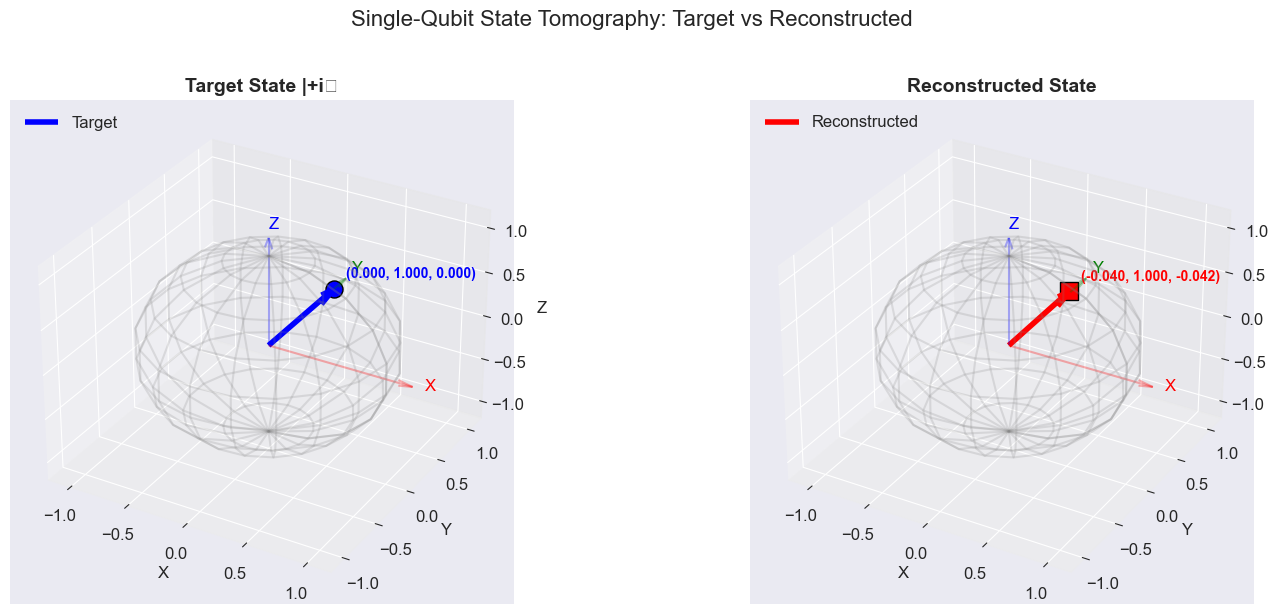

In [18]:
x_target, y_target, z_target = 0.000, 1.000, 0.000  # |+i⟩ state
x_recon, y_recon, z_recon = x, y, z

# Create figure with two subplots
fig = plt.figure(figsize=(16, 6))

# ============================================
# LEFT PLOT: Target State
# ============================================
ax1 = fig.add_subplot(121, projection='3d')

# Draw Bloch sphere wireframe
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x_sphere = np.sin(v) * np.cos(u)
y_sphere = np.sin(v) * np.sin(u)
z_sphere = np.cos(v)
ax1.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.2)

# Draw axes
ax1.quiver(0, 0, 0, 1.2, 0, 0, color='red', alpha=0.3, arrow_length_ratio=0.1)
ax1.quiver(0, 0, 0, 0, 1.2, 0, color='green', alpha=0.3, arrow_length_ratio=0.1)
ax1.quiver(0, 0, 0, 0, 0, 1.2, color='blue', alpha=0.3, arrow_length_ratio=0.1)

# Add axis labels
ax1.text(1.3, 0, 0, 'X', color='red', fontsize=12)
ax1.text(0, 1.3, 0, 'Y', color='green', fontsize=12)
ax1.text(0, 0, 1.3, 'Z', color='blue', fontsize=12)

# Plot target state
ax1.quiver(0, 0, 0, x_target, y_target, z_target, 
           color='blue', linewidth=4, arrow_length_ratio=0.2, label='Target')
ax1.scatter([x_target], [y_target], [z_target], color='blue', s=150, edgecolor='black')

# Add coordinate text
ax1.text(x_target*1.2, y_target*1.2, z_target*1.2, 
         f'({x_target:.3f}, {y_target:.3f}, {z_target:.3f})', 
         color='blue', fontsize=10, fontweight='bold')

ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([-1.2, 1.2])
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('Z', fontsize=12)
ax1.set_title('Target State |+i⟩', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

# ============================================
# RIGHT PLOT: Reconstructed State
# ============================================
ax2 = fig.add_subplot(122, projection='3d')

# Draw Bloch sphere wireframe
ax2.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.2)

# Draw axes
ax2.quiver(0, 0, 0, 1.2, 0, 0, color='red', alpha=0.3, arrow_length_ratio=0.1)
ax2.quiver(0, 0, 0, 0, 1.2, 0, color='green', alpha=0.3, arrow_length_ratio=0.1)
ax2.quiver(0, 0, 0, 0, 0, 1.2, color='blue', alpha=0.3, arrow_length_ratio=0.1)

# Add axis labels
ax2.text(1.3, 0, 0, 'X', color='red', fontsize=12)
ax2.text(0, 1.3, 0, 'Y', color='green', fontsize=12)
ax2.text(0, 0, 1.3, 'Z', color='blue', fontsize=12)

# Plot reconstructed state
ax2.quiver(0, 0, 0, x_recon, y_recon, z_recon, 
           color='red', linewidth=4, arrow_length_ratio=0.2, label='Reconstructed')
ax2.scatter([x_recon], [y_recon], [z_recon], color='red', s=150, marker='s', edgecolor='black')

# Add coordinate text
ax2.text(x_recon*1.2, y_recon*1.2, z_recon*1.2, 
         f'({x_recon:.3f}, {y_recon:.3f}, {z_recon:.3f})', 
         color='red', fontsize=10, fontweight='bold')

ax2.set_xlim([-1.2, 1.2])
ax2.set_ylim([-1.2, 1.2])
ax2.set_zlim([-1.2, 1.2])
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_zlabel('Z', fontsize=12)
ax2.set_title('Reconstructed State', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')

plt.suptitle('Single-Qubit State Tomography: Target vs Reconstructed', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Single-qubit state tomography using linear inversion for mixed density matrix: $$ \rho = \frac{I}{2} = \frac{1}{2} \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} $$

In [9]:
psi0 = basis(2, 0)           # |0⟩
psi1 = basis(2, 1)           # |1⟩
rho = 0.5 * ket2dm(psi0) + 0.5 * ket2dm(psi1)


print("\nDensity matrix:")
print(np.round(rho.full(), 4))

# Calculate Bloch vector components
x_exp = np.real((rho * sigmax()).tr())
y_exp = np.real((rho * sigmay()).tr())
z_exp = np.real((rho * sigmaz()).tr())

print(f"\nBloch vector components:")
print(f"⟨σ_x⟩ = {x_exp:.4f}")
print(f"⟨σ_y⟩ = {y_exp:.4f}")
print(f"⟨σ_z⟩ = {z_exp:.4f}")


Density matrix:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Bloch vector components:
⟨σ_x⟩ = 0.0000
⟨σ_y⟩ = 0.0000
⟨σ_z⟩ = 0.0000


In [13]:
n_shots = 1000  # Number of measurements per basis
measurement_results_1 = {'Z': [], 'X': [], 'Y': []}
x=0
y=0
z=0

print(f"Simulating {n_shots} measurements in each basis...\n")

for basis_name in ['Z', 'X', 'Y']:
    # Select the measurement operator
    if basis_name == 'Z':
        operator = sigmaz()
    elif basis_name == 'X':
        operator = sigmax()
    else:  # Y
        operator = sigmay()
    
    print(f"\n{basis_name}-basis measurements:")
    
    # Perform n_shots individual measurements
    for shot in range(n_shots):
        # Each measurement needs a fresh copy of the state
        # (In real experiments, each shot uses a new identical copy)
        fresh_state = rho.copy()
        
        # Measure using QuTiP's measure function
        # measure returns: (collapsed_state, measurement_result)
        # measurement_result is +1 or -1 for Pauli operators
        result, collapsed_state = measure(fresh_state, operator)
        
        # Store the result (+1 or -1)
        measurement_results_1[basis_name].append(result)
        
    # Calculate statistics
    results_array = np.array(measurement_results_1[basis_name])
    count_plus = np.sum(results_array == 1)   # +1 outcome
    count_minus = np.sum(results_array == -1)  # -1 outcome

    prob_plus = count_plus / n_shots
    prob_minus = count_minus / n_shots

    if basis_name == 'Z':
        z = 2 * prob_plus - 1
    elif basis_name == 'X':
        x = 2 * prob_plus - 1
    else:  # Y
        y = 2 * prob_plus - 1
    
    print(f"  Counts: +1: {count_plus:5d}, -1: {count_minus:5d}")
    print(f"  Probabilities: P(+1) = {prob_plus:.4f}, P(-1) = {prob_minus:.4f}")
  


Simulating 1000 measurements in each basis...


Z-basis measurements:
  Counts: +1:   496, -1:   504
  Probabilities: P(+1) = 0.4960, P(-1) = 0.5040

X-basis measurements:
  Counts: +1:   489, -1:   511
  Probabilities: P(+1) = 0.4890, P(-1) = 0.5110

Y-basis measurements:
  Counts: +1:   464, -1:   536
  Probabilities: P(+1) = 0.4640, P(-1) = 0.5360


In [14]:
#Now reconstructing the density matrix
I = qeye(2)
reconstructed_rho1 = (I + x*sigmax() + y*sigmay() + z*sigmaz()) / 2
print(reconstructed_rho1)
#Check whether reconstructed density matrix is a physical state
check_physicality(reconstructed_rho1)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.496+0.j    -0.011+0.036j]
 [-0.011-0.036j  0.504+0.j   ]]


{'is_physical': np.True_,
 'is_hermitian': True,
 'trace': 1.0,
 'trace_ok': True,
 'eigenvalues': array([0.46214501, 0.53785499]),
 'positive_ok': np.True_,
 'purity': 0.502866,
 'purity_ok': True,
 'bloch_vector': (-0.02200000000000002,
  -0.07199999999999995,
  -0.008000000000000007),
 'bloch_length': np.float64(0.07570997292299075),
 'bloch_ok': np.True_}

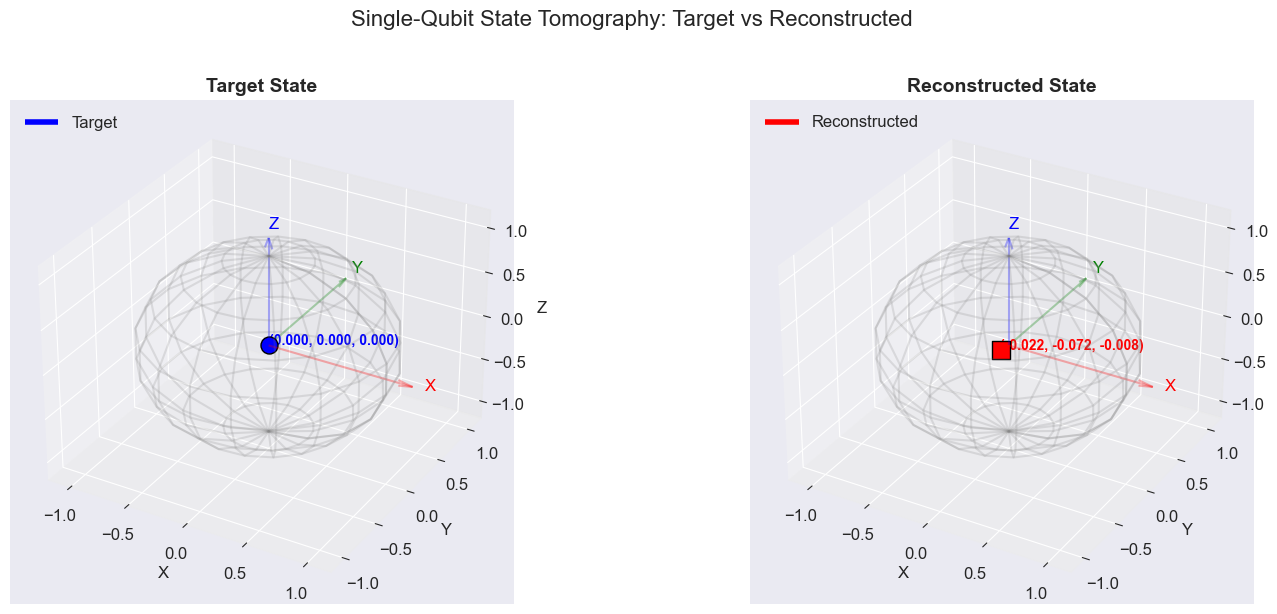

In [15]:
x_target, y_target, z_target = 0.000, 0.000, 0.000  # maximally mixed state
x_recon, y_recon, z_recon = x, y, z

# Create figure with two subplots
fig = plt.figure(figsize=(16, 6))

# ============================================
# LEFT PLOT: Target State
# ============================================
ax1 = fig.add_subplot(121, projection='3d')

# Draw Bloch sphere wireframe
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x_sphere = np.sin(v) * np.cos(u)
y_sphere = np.sin(v) * np.sin(u)
z_sphere = np.cos(v)
ax1.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.2)

# Draw axes
ax1.quiver(0, 0, 0, 1.2, 0, 0, color='red', alpha=0.3, arrow_length_ratio=0.1)
ax1.quiver(0, 0, 0, 0, 1.2, 0, color='green', alpha=0.3, arrow_length_ratio=0.1)
ax1.quiver(0, 0, 0, 0, 0, 1.2, color='blue', alpha=0.3, arrow_length_ratio=0.1)

# Add axis labels
ax1.text(1.3, 0, 0, 'X', color='red', fontsize=12)
ax1.text(0, 1.3, 0, 'Y', color='green', fontsize=12)
ax1.text(0, 0, 1.3, 'Z', color='blue', fontsize=12)

# Plot target state
ax1.quiver(0, 0, 0, x_target, y_target, z_target, 
           color='blue', linewidth=4, arrow_length_ratio=0.2, label='Target')
ax1.scatter([x_target], [y_target], [z_target], color='blue', s=150, edgecolor='black')

# Add coordinate text
ax1.text(x_target*1.2, y_target*1.2, z_target*1.2, 
         f'({x_target:.3f}, {y_target:.3f}, {z_target:.3f})', 
         color='blue', fontsize=10, fontweight='bold')

ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([-1.2, 1.2])
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('Z', fontsize=12)
ax1.set_title('Target State', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

# ============================================
# RIGHT PLOT: Reconstructed State
# ============================================
ax2 = fig.add_subplot(122, projection='3d')

# Draw Bloch sphere wireframe
ax2.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.2)

# Draw axes
ax2.quiver(0, 0, 0, 1.2, 0, 0, color='red', alpha=0.3, arrow_length_ratio=0.1)
ax2.quiver(0, 0, 0, 0, 1.2, 0, color='green', alpha=0.3, arrow_length_ratio=0.1)
ax2.quiver(0, 0, 0, 0, 0, 1.2, color='blue', alpha=0.3, arrow_length_ratio=0.1)

# Add axis labels
ax2.text(1.3, 0, 0, 'X', color='red', fontsize=12)
ax2.text(0, 1.3, 0, 'Y', color='green', fontsize=12)
ax2.text(0, 0, 1.3, 'Z', color='blue', fontsize=12)

# Plot reconstructed state
ax2.quiver(0, 0, 0, x_recon, y_recon, z_recon, 
           color='red', linewidth=4, arrow_length_ratio=0.2, label='Reconstructed')
ax2.scatter([x_recon], [y_recon], [z_recon], color='red', s=150, marker='s', edgecolor='black')

# Add coordinate text
ax2.text(x_recon*1.2, y_recon*1.2, z_recon*1.2, 
         f'({x_recon:.3f}, {y_recon:.3f}, {z_recon:.3f})', 
         color='red', fontsize=10, fontweight='bold')

ax2.set_xlim([-1.2, 1.2])
ax2.set_ylim([-1.2, 1.2])
ax2.set_zlim([-1.2, 1.2])
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_zlabel('Z', fontsize=12)
ax2.set_title('Reconstructed State', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')

plt.suptitle('Single-Qubit State Tomography: Target vs Reconstructed', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()